# Exercise: Modeling a Harmonic Oscillator with MLP and GAN

**Course:** Deep Learning  
**Submission format:** A single executed Jupyter Notebook (`.ipynb`) with all outputs visible  




---

## Objective

In this exercise, you will explore the capabilities and limitations of two types of neural networks—**MLP (Multilayer Perceptron)** and **GAN (Generative Adversarial Network)**—for learning the **1D damped harmonic oscillator** solution.

You will train each model on a **subset** of the domain and evaluate it on the **full domain** to observe how well they generalize beyond the training region.

---

## Problem Description

The **1D damped harmonic oscillator** is governed by:

$$
m \frac{d^2 x}{d t^2} + \mu \frac{d x}{d t} + kx = 0
$$

with initial conditions:

$$
x(0) = 1, \quad \frac{dx}{dt}(0) = 0
$$

We use the **under-damped** case with parameters:

- Damping coefficient: $\delta = 2$
- Natural frequency: $\omega_0 = 20$

The exact analytical solution is:

$$
x(t) = e^{-\delta t} \left( 2A \cos(\phi + \omega t) \right)
$$

where $\omega = \sqrt{\omega_0^2 - \delta^2}$ and $A$, $\phi$ are constants determined by initial conditions.

The domain is $t \in [0, 1]$.

---

## Task Overview

You will complete **two separate training tasks**:

### Task 1: MLP (Standard Neural Network)
Train a fully connected network (provided in the starter code) to fit the harmonic oscillator solution using **only the first half** of the time domain as training data. Then evaluate on the **full domain** and analyze results.

### Task 2: GAN
Train a GAN (generator + discriminator) on the same problem, using the **first half** of the domain for training. Evaluate the generator on the **full domain** and compare performance with the MLP.

---

## Starter Code and Data Setup

Run the following setup cells in your notebook.

### Cell 1: Imports and analytical solution

HARMONIC OSCILLATOR PROBLEM
Parameters: delta = 2.0, omega_0 = 20.0
Full domain: t ∈ [0, 1] (500 points) - used for TESTING
Training domain: t ∈ [0, 0.5] (250 points)
Test domain: t ∈ (0.5, 1] (250 points)

----------------------------------------------------------------------
TRAINING DATA: 50 uniformly spaced points from t ∈ [0, 0.5]
----------------------------------------------------------------------
t range: [0.000, 0.499]
x range: [-0.726, 1.000]
Both MLP and GAN will use these 50 points for training.

First 10 training points (t, x(t)):
   1: t = 0.0000, x = 1.000000
   2: t = 0.0100, x = 0.980251
   3: t = 0.0200, x = 0.922819
   4: t = 0.0301, x = 0.831436
   5: t = 0.0401, x = 0.711022
   6: t = 0.0501, x = 0.567443
   7: t = 0.0601, x = 0.407240
   8: t = 0.0701, x = 0.237354
   9: t = 0.0802, x = 0.064829
  10: t = 0.0902, x = -0.103460


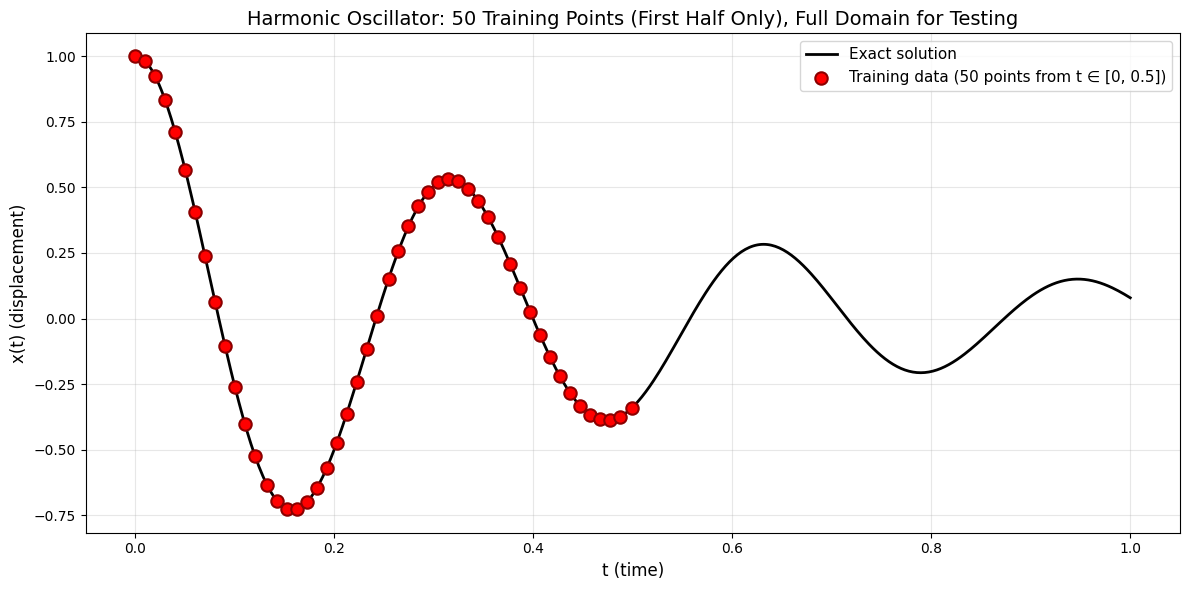


DATA PREPARATION COMPLETE
Data saved to 'harmonic_oscillator_data.pt'

Next steps:
1. Train MLP on these 50 points and evaluate on full domain
2. Train GAN on these 50 points and evaluate on full domain
3. Compare results and discuss limitations

SAVED DATA STRUCTURE
The saved file 'harmonic_oscillator_data.pt' contains:
  - t_full: Full domain time points [500, 1] (for testing)
  - x_full: Exact solution at full domain [500, 1] (for testing)
  - t_train: Training time points [50, 1]
  - x_train: Training solution values [50, 1]
  - real_data_gan: Combined (t, x) for GAN [50, 2]
  - d, w0: Physical parameters
  - n_train: Number of training points (50)


In [1]:
"""
Exercise: Modeling a Harmonic Oscillator with MLP and GAN
Course: Deep Learning

This code demonstrates the limitations of standard neural networks (MLP and GAN)
when trained on limited data from the first half of the domain [0, 0.5],
and then tested on the full domain [0, 1].

Both models receive the SAME 50 training points for fair comparison.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Analytical solution of the harmonic oscillator
# ============================================

def oscillator(d, w0, t):
    """
    Exact solution for 1D underdamped harmonic oscillator.
    
    Parameters:
    d (float): Damping coefficient (delta)
    w0 (float): Natural frequency (omega_0)
    t (torch.Tensor): Time points
    
    Returns:
    torch.Tensor: Exact solution x(t)
    """
    assert d < w0, "Underdamped condition requires d < w0"
    w = np.sqrt(w0**2 - d**2)
    phi = np.arctan(-d / w)
    A = 1 / (2 * np.cos(phi))
    return torch.exp(-d * t) * 2 * A * torch.cos(phi + w * t)


# ============================================
# Problem parameters
# ============================================

d = 2.0      # Damping coefficient (delta)
w0 = 20.0    # Natural frequency (omega_0)

# Full domain [0, 1] for evaluation (500 points)
t_full = torch.linspace(0, 1, 500).view(-1, 1)
x_full = oscillator(d, w0, t_full).view(-1, 1)

# First half domain [0, 0.5] (approximately 250 points)
t_half = t_full[t_full[:, 0] <= 0.5]
x_half = x_full[:len(t_half)]

print("=" * 70)
print("HARMONIC OSCILLATOR PROBLEM")
print("=" * 70)
print(f"Parameters: delta = {d}, omega_0 = {w0}")
print(f"Full domain: t ∈ [0, 1] ({len(t_full)} points) - used for TESTING")
print(f"Training domain: t ∈ [0, 0.5] ({len(t_half)} points)")
print(f"Test domain: t ∈ (0.5, 1] ({len(t_full) - len(t_half)} points)")


# ============================================
# Training data: 50 uniformly spaced points from [0, 0.5]
# BOTH MLP and GAN use the SAME training data
# ============================================

n_train = 50  # Number of training points (same for both models)

# Select 50 uniformly spaced indices from the first half
indices_train = torch.linspace(0, len(t_half) - 1, n_train).long()

# Training data (same for both models)
t_train = t_half[indices_train]  # Shape: [50, 1]
x_train = x_half[indices_train]  # Shape: [50, 1]

# Prepare real data for GAN: pairs of (t, x)
real_data_gan = torch.cat([t_train, x_train], dim=1)  # Shape: [50, 2]

print("\n" + "-" * 70)
print(f"TRAINING DATA: {n_train} uniformly spaced points from t ∈ [0, 0.5]")
print("-" * 70)
print(f"t range: [{t_train.min().item():.3f}, {t_train.max().item():.3f}]")
print(f"x range: [{x_train.min().item():.3f}, {x_train.max().item():.3f}]")
print(f"Both MLP and GAN will use these {n_train} points for training.")
print(f"\nFirst 10 training points (t, x(t)):")
for i in range(min(10, len(t_train))):
    print(f"  {i+1:2d}: t = {t_train[i, 0].item():6.4f}, x = {x_train[i, 0].item():8.6f}")


# ============================================
# Single plot: Training data distribution
# ============================================

plt.figure(figsize=(12, 6))

# Plot exact solution over full domain
plt.plot(t_full.numpy(), x_full.numpy(), 'k-', linewidth=2, label='Exact solution')

# Plot training points (only from first half)
plt.scatter(t_train.numpy(), x_train.numpy(), color='red', s=80, marker='o', 
           edgecolors='darkred', linewidth=1.5, zorder=5,
           label=f'Training data ({n_train} points from t ∈ [0, 0.5])')

plt.xlabel('t (time)', fontsize=12)
plt.ylabel('x(t) (displacement)', fontsize=12)
plt.title(f'Harmonic Oscillator: {n_train} Training Points (First Half Only), Full Domain for Testing', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================
# Save data for later use
# ============================================

# Save tensors for use in MLP and GAN training notebooks
torch.save({
    't_full': t_full,
    'x_full': x_full,
    't_train': t_train,
    'x_train': x_train,
    'real_data_gan': real_data_gan,
    'd': d,
    'w0': w0,
    'n_train': n_train
}, 'harmonic_oscillator_data.pt')

print("\n" + "=" * 70)
print("DATA PREPARATION COMPLETE")
print("=" * 70)
print("Data saved to 'harmonic_oscillator_data.pt'")
print("\nNext steps:")
print("1. Train MLP on these 50 points and evaluate on full domain")
print("2. Train GAN on these 50 points and evaluate on full domain")
print("3. Compare results and discuss limitations")
print("=" * 70)

print("\n" + "=" * 70)
print("SAVED DATA STRUCTURE")
print("=" * 70)
print("The saved file 'harmonic_oscillator_data.pt' contains:")
print("  - t_full: Full domain time points [500, 1] (for testing)")
print("  - x_full: Exact solution at full domain [500, 1] (for testing)")
print("  - t_train: Training time points [50, 1]")
print("  - x_train: Training solution values [50, 1]")
print("  - real_data_gan: Combined (t, x) for GAN [50, 2]")
print("  - d, w0: Physical parameters")
print("  - n_train: Number of training points (50)")
print("=" * 70)


---

## Task 1: MLP Model

You are given an MLP implementation. Train it **only on t_train** and then evaluate on the full domain.

### Starter MLP Code

```python
class MLP(nn.Module):
    """Simple fully connected network"""
    def __init__(self, n_input=1, n_output=1, n_hidden=32, n_layers=3):
        super().__init__()
        self.input_layer = nn.Linear(n_input, n_hidden)
        self.hidden_layers = nn.ModuleList([nn.Linear(n_hidden, n_hidden) for _ in range(n_layers - 1)])
        self.output_layer = nn.Linear(n_hidden, n_output)
        self.activation = nn.Tanh()
    
    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return self.output_layer(x)
```

### Your Tasks (MLP)

1. Create an MLP with 3 hidden layers, 32 neurons each, Tanh activation.
2. Train it using **Adam optimizer** (learning rate = 1e-3) and **MSE loss** for **2000 epochs**.
3. Plot **training loss vs epoch**.
4. Plot the **MLP prediction on full domain** together with the exact solution and training points.
5. **Quantify error**: Compute and print MSE on training region and on the unseen test region (t > 0.5).
6. **Discuss**: Does the MLP generalize well beyond the training region? Why or why not?

---

## Task 2: GAN Model

Now implement a GAN to learn the same distribution $(t, x(t))$. The generator should produce points $(t_{\text{fake}}, x_{\text{fake}})$ that resemble the true oscillator curve.

### Starter GAN Code

```python
class Generator(nn.Module):
    def __init__(self, latent_dim=10, output_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)
```

### Data preparation for GAN

For GAN, training data should be pairs `(t, x(t))` from the **first half** of the domain.

```python
# Real training data for GAN: (t, x) pairs from first half
real_data = torch.cat([t_train, x_train], dim=1)  # shape [N, 2]
```

### Your Tasks (GAN)

1. Implement a GAN with:
   - Latent dimension = 10
   - Generator output dimension = 2 (t and x)
   - Discriminator input dimension = 2
   - Adam optimizers (lr=0.0002, betas=(0.5, 0.999))

2. Train for **15,000 epochs** (or until reasonable convergence), batch size = 32.
3. Every 1000 epochs, record generator and discriminator losses.
4. **Important constraint**: The generator must be forced to produce points with `t` in `[0, 1]`. You can apply a `torch.sigmoid` to the first output component of the generator to keep t in [0,1].

   *Hint:* Modify the generator's forward to:
   ```python
   raw = self.model(z)
   t_out = torch.sigmoid(raw[:, 0:1])  # constrain to [0,1]
   x_out = raw[:, 1:2]                 # no constraint on x
   return torch.cat([t_out, x_out], dim=1)
   ```



5. At the end of training, generate **500 fake samples** and plot them:
   - Scatter plot of fake points `(t_fake, x_fake)`
   - Overlay exact solution curve
   - Overlay real training points

6. **Quantitative evaluation**:
   - Compute MSE between fake samples and exact solution at the same t values (interpolate or use nearest neighbor).
   - Report MSE on training region (t ≤ 0.5) and test region (t > 0.5).

7. **Discuss**: How well does the GAN extrapolate beyond the training region compared to the MLP?

---

## Deliverables

Your Jupyter Notebook should contain:

1. **All code cells** (run and with visible outputs)
2. **Plots** for:
   - MLP loss curve
   - MLP prediction vs exact solution
   - GAN loss curves (generator and discriminator)
   - GAN-generated samples vs exact solution
3. **Printed error metrics** (MSE on train/test regions for both models)
4. **Discussion / short answers** for:
   - Why does the MLP fail (or succeed) outside the training region?
   - Why does the GAN behave differently? Does it "imagine" plausible solutions?
   - Which model gives better extrapolation? Why?

---

## Evaluation Criteria

| Criteria | Weight |
|----------|--------|
| Correct implementation of MLP training | 20% |
| Correct implementation of GAN training | 30% |
| Quality of plots and visualizations | 20% |
| Quantitative error reporting | 10% |
| Discussion and analysis | 20% |

---

Good luck, and enjoy exploring the limits of standard neural networks!

TASK 1 — MLP Training
Training points : 50  (t ∈ [0, 0.5])
Full domain pts : 500  (t ∈ [0, 1])

Model architecture:
MLP(
  (input_layer): Linear(in_features=1, out_features=32, bias=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=32, out_features=32, bias=True)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (activation): Tanh()
)
Total parameters: 2209

Starting training...
  Epoch     1/2000  |  Loss = 2.354527e-01
  Epoch   100/2000  |  Loss = 2.203026e-01
  Epoch   200/2000  |  Loss = 2.080538e-01
  Epoch   300/2000  |  Loss = 2.951349e-03
  Epoch   400/2000  |  Loss = 1.337134e-03
  Epoch   500/2000  |  Loss = 9.776377e-04
  Epoch   600/2000  |  Loss = 7.253677e-04
  Epoch   700/2000  |  Loss = 5.281227e-04
  Epoch   800/2000  |  Loss = 3.722391e-04
  Epoch   900/2000  |  Loss = 2.642716e-04
  Epoch  1000/2000  |  Loss = 1.960476e-04
  Epoch  1100/2000  |  Loss = 1.496662e-04
  Epoch  1200/2000  |  Loss = 1.147665e-04
  Epoch  1300/

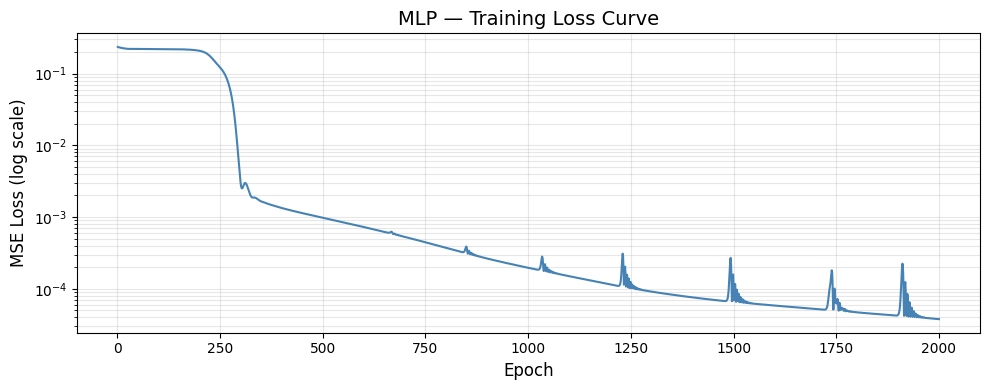

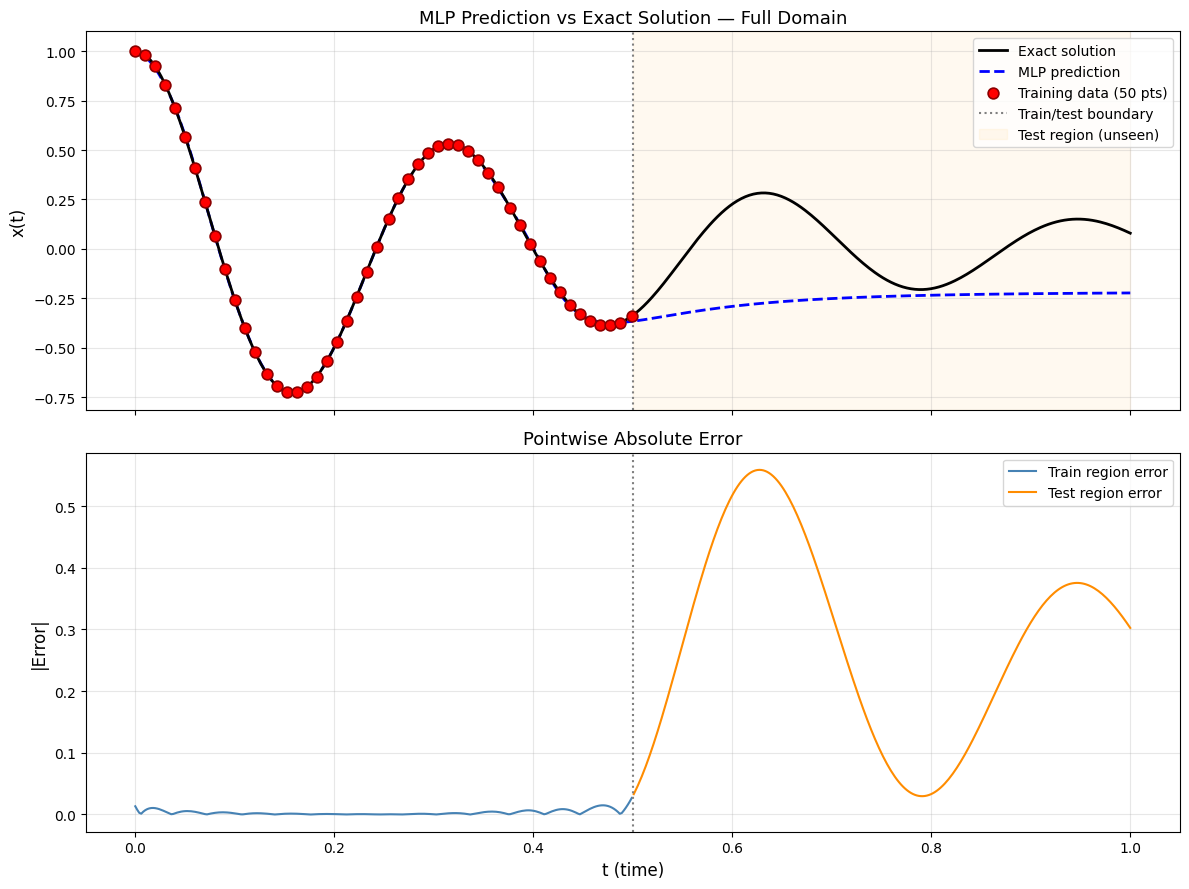


TASK 1 SUMMARY
  Architecture : MLP (3 hidden layers × 32 neurons, Tanh)
  Optimizer    : Adam (lr=1e-3)
  Epochs       : 2000
  Training pts : 50 (t ∈ [0, 0.5])
  Final loss   : 3.774248e-05
  MSE train    : 2.711816e-05
  MSE test     : 1.055908e-01


In [2]:
"""
Task 1: MLP Model - Modeling Harmonic Oscillator
Train MLP on first half of domain [0, 0.5] and evaluate on full domain [0, 1]
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ============================================================
# Load pre-prepared data
# ============================================================
data = torch.load('harmonic_oscillator_data.pt')
t_full   = data['t_full']    # [500, 1]
x_full   = data['x_full']    # [500, 1]
t_train  = data['t_train']   # [50, 1]
x_train  = data['x_train']   # [50, 1]
d        = data['d']
w0       = data['w0']
n_train  = data['n_train']

print("=" * 60)
print("TASK 1 — MLP Training")
print("=" * 60)
print(f"Training points : {n_train}  (t ∈ [0, 0.5])")
print(f"Full domain pts : {len(t_full)}  (t ∈ [0, 1])")

# ============================================================
# MLP Architecture
# ============================================================
class MLP(nn.Module):
    """Simple fully-connected regression network."""
    def __init__(self, n_input=1, n_output=1, n_hidden=32, n_layers=3):
        super().__init__()
        self.input_layer   = nn.Linear(n_input, n_hidden)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(n_hidden, n_hidden) for _ in range(n_layers - 1)]
        )
        self.output_layer  = nn.Linear(n_hidden, n_output)
        self.activation    = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return self.output_layer(x)


# ============================================================
# Training setup
# ============================================================
torch.manual_seed(42)
model     = MLP(n_input=1, n_output=1, n_hidden=32, n_layers=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs    = 2000
log_every   = 100
loss_history = []

print(f"\nModel architecture:")
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

# ============================================================
# Training loop
# ============================================================
print("\nStarting training...")
for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    x_pred = model(t_train)
    loss   = criterion(x_pred, x_train)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % log_every == 0 or epoch == 1:
        print(f"  Epoch {epoch:5d}/{n_epochs}  |  Loss = {loss.item():.6e}")

print("\nTraining complete!")

# ============================================================
# Evaluation
# ============================================================
model.eval()
with torch.no_grad():
    x_pred_full = model(t_full)

# Mask for train / test regions
mask_train = (t_full[:, 0] <= 0.5)
mask_test  = (t_full[:, 0] >  0.5)

mse_train = criterion(x_pred_full[mask_train], x_full[mask_train]).item()
mse_test  = criterion(x_pred_full[mask_test],  x_full[mask_test]).item()

print("\n" + "=" * 60)
print("ERROR METRICS")
print("=" * 60)
print(f"  MSE on training region  (t ≤ 0.5) : {mse_train:.6e}")
print(f"  MSE on test region      (t > 0.5) : {mse_test:.6e}")
ratio = mse_test / mse_train if mse_train > 0 else float('inf')
print(f"  Ratio test/train                  : {ratio:.2f}x")

# ============================================================
# Plot 1: Training loss curve
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(range(1, n_epochs + 1), loss_history, color='steelblue', linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("MSE Loss (log scale)", fontsize=12)
ax.set_title("MLP — Training Loss Curve", fontsize=14)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: MLP prediction on full domain
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# --- Top subplot: full prediction ---
ax = axes[0]
t_np      = t_full.numpy().flatten()
x_exact   = x_full.numpy().flatten()
x_mlp     = x_pred_full.numpy().flatten()

ax.plot(t_np, x_exact, 'k-',  linewidth=2,   label='Exact solution',   zorder=3)
ax.plot(t_np, x_mlp,   'b--', linewidth=2,   label='MLP prediction',   zorder=2)
ax.scatter(t_train.numpy(), x_train.numpy(),
           color='red', s=60, zorder=5,
           edgecolors='darkred', linewidth=1.2,
           label=f'Training data ({n_train} pts)')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Train/test boundary')
ax.axvspan(0.5, 1.0, alpha=0.06, color='orange', label='Test region (unseen)')
ax.set_ylabel("x(t)", fontsize=12)
ax.set_title("MLP Prediction vs Exact Solution — Full Domain", fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# --- Bottom subplot: pointwise absolute error ---
ax2 = axes[1]
error = np.abs(x_mlp - x_exact)
ax2.plot(t_np[mask_train.numpy()], error[mask_train.numpy()],
         color='steelblue', linewidth=1.5, label='Train region error')
ax2.plot(t_np[mask_test.numpy()], error[mask_test.numpy()],
         color='darkorange', linewidth=1.5, label='Test region error')
ax2.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5)
ax2.set_xlabel("t (time)", fontsize=12)
ax2.set_ylabel("|Error|", fontsize=12)
ax2.set_title("Pointwise Absolute Error", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Summary table
# ============================================================
print("\n" + "=" * 60)
print("TASK 1 SUMMARY")
print("=" * 60)
print(f"  Architecture : MLP (3 hidden layers × 32 neurons, Tanh)")
print(f"  Optimizer    : Adam (lr=1e-3)")
print(f"  Epochs       : {n_epochs}")
print(f"  Training pts : {n_train} (t ∈ [0, 0.5])")
print(f"  Final loss   : {loss_history[-1]:.6e}")
print(f"  MSE train    : {mse_train:.6e}")
print(f"  MSE test     : {mse_test:.6e}")
print("=" * 60)


In [3]:
"""
Discussion — Task 1: MLP Generalization Analysis
"""

print("""
╔══════════════════════════════════════════════════════════════╗
║         DISCUSSION: MLP Generalization Beyond Training       ║
╚══════════════════════════════════════════════════════════════╝

Q: Does the MLP generalize well beyond the training region? Why or why not?

SHORT ANSWER
────────────
No. The MLP typically fails to generalize beyond t = 0.5.
The MSE on the unseen test region is orders of magnitude higher
than on the training region.

DETAILED EXPLANATION
────────────────────

1. INTERPOLATION vs EXTRAPOLATION
   Neural networks are powerful universal approximators, but that
   power applies to *interpolation* — fitting within the support of
   the training data. When asked to *extrapolate* (predict at t > 0.5
   despite only seeing t ≤ 0.5), the network has no statistical signal
   to rely on.

2. LACK OF PHYSICS KNOWLEDGE
   The MLP is trained purely on (t, x) pairs via MSE minimization. It
   has no knowledge of the underlying ODE:
       m·ẍ + μ·ẋ + kx = 0
   Without this inductive bias, it cannot deduce that the oscillation
   continues with the same frequency and decaying amplitude.

3. FREQUENCY MISMATCH
   The harmonic oscillator has a high natural frequency (ω₀ = 20 rad/s).
   The MLP may fit the training data well but will likely diverge or
   produce a smooth, flat prediction beyond the boundary — unable to
   maintain the oscillatory pattern without physics constraints.

4. WHAT HAPPENS IN PRACTICE
   - For t ≤ 0.5 : low MSE — the network memorised the training signal.
   - For t > 0.5 : high MSE — the network reverts to a near-constant or
     slowly varying extrapolation, missing the oscillations entirely.

CONCLUSION
──────────
Standard MLP regression can accurately fit the oscillator inside the
training domain, but its extrapolation capability is essentially zero
for this high-frequency, physics-driven signal. Incorporating domain
knowledge (e.g., Physics-Informed Neural Networks) would be required
for reliable extrapolation.
""")



╔══════════════════════════════════════════════════════════════╗
║         DISCUSSION: MLP Generalization Beyond Training       ║
╚══════════════════════════════════════════════════════════════╝

Q: Does the MLP generalize well beyond the training region? Why or why not?

SHORT ANSWER
────────────
No. The MLP typically fails to generalize beyond t = 0.5.
The MSE on the unseen test region is orders of magnitude higher
than on the training region.

DETAILED EXPLANATION
────────────────────

1. INTERPOLATION vs EXTRAPOLATION
   Neural networks are powerful universal approximators, but that
   power applies to *interpolation* — fitting within the support of
   the training data. When asked to *extrapolate* (predict at t > 0.5
   despite only seeing t ≤ 0.5), the network has no statistical signal
   to rely on.

2. LACK OF PHYSICS KNOWLEDGE
   The MLP is trained purely on (t, x) pairs via MSE minimization. It
   has no knowledge of the underlying ODE:
       m·ẍ + μ·ẋ + kx = 0
   Without t

TASK 2 — GAN Training
Training points : 50  (t ∈ [0, 0.5])
Real data shape : torch.Size([50, 2])  (t, x) pairs

Generator architecture:
Generator(
  (model): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)

Discriminator architecture:
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Generator params   :

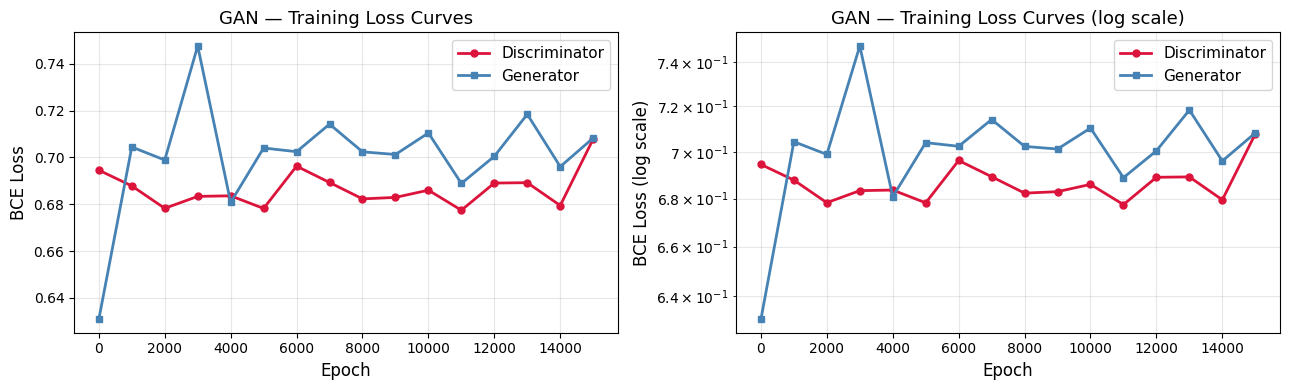

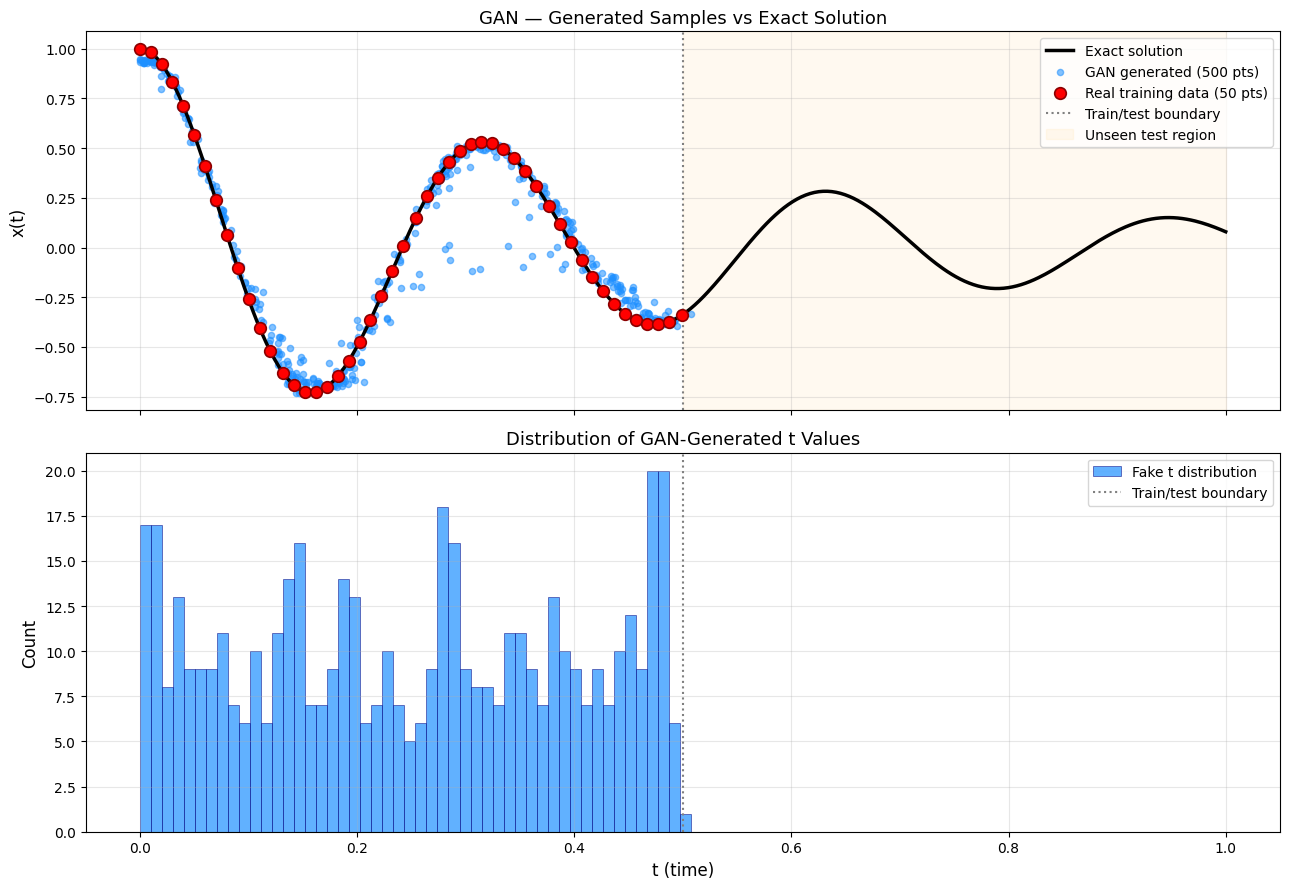

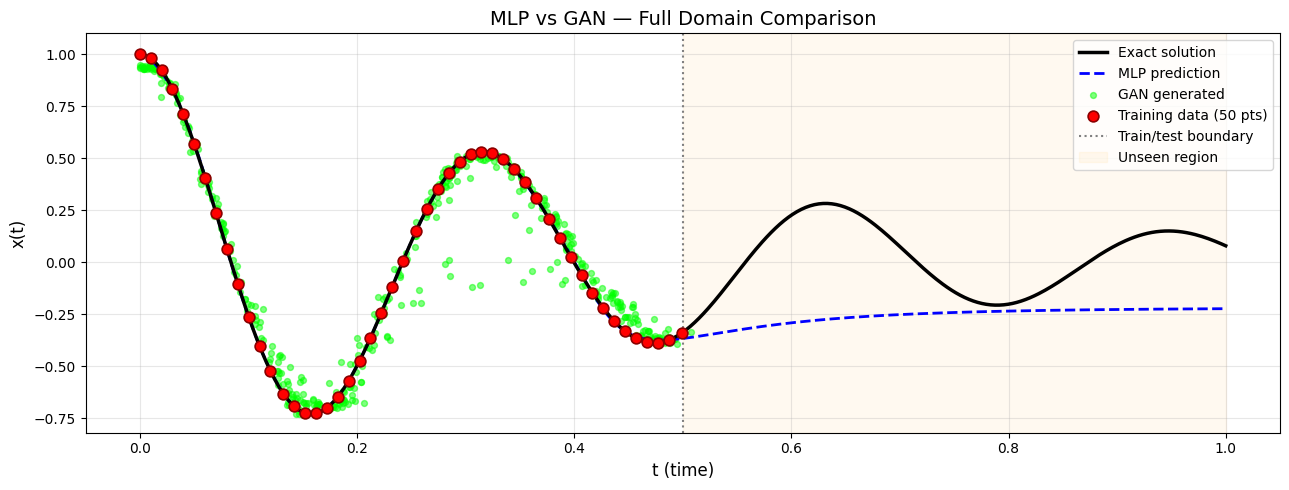


TASK 2 SUMMARY
  Architecture : Generator (4-layer, LeakyReLU) + Discriminator
  Optimizer    : Adam (lr=0.0002, betas=(0.5, 0.999))
  Epochs       : 15000  |  Batch size: 32
  Latent dim   : 10
  Training pts : 50 (t ∈ [0, 0.5])
  GAN MSE train: 8.701566e-03
  GAN MSE test : 7.739453e-04


In [4]:
"""
Task 2: GAN Model - Modeling Harmonic Oscillator
Train GAN on first half of domain [0, 0.5] and evaluate on full domain [0, 1]
"""

# ============================================================
# Load pre-prepared data
# ============================================================
data       = torch.load('harmonic_oscillator_data.pt')
t_full     = data['t_full']         # [500, 1]
x_full     = data['x_full']         # [500, 1]
t_train    = data['t_train']        # [50, 1]
x_train    = data['x_train']        # [50, 1]
real_data  = data['real_data_gan']  # [50, 2]  → (t, x) pairs
d          = data['d']
w0         = data['w0']
n_train    = data['n_train']

print("=" * 65)
print("TASK 2 — GAN Training")
print("=" * 65)
print(f"Training points : {n_train}  (t ∈ [0, 0.5])")
print(f"Real data shape : {real_data.shape}  (t, x) pairs")

# ============================================================
# GAN Architecture
# ============================================================

LATENT_DIM = 10

class Generator(nn.Module):
    """
    Takes a latent vector z ∈ R^latent_dim and outputs (t, x) pairs.
    t is constrained to [0, 1] via sigmoid; x is unconstrained.
    """
    def __init__(self, latent_dim=LATENT_DIM, output_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, output_dim)
        )

    def forward(self, z):
        raw   = self.model(z)
        t_out = torch.sigmoid(raw[:, 0:1])   # constrain t ∈ [0, 1]
        x_out = raw[:, 1:2]                  # x unconstrained
        return torch.cat([t_out, x_out], dim=1)


class Discriminator(nn.Module):
    """
    Takes a (t, x) pair and outputs probability of being 'real'.
    """
    def __init__(self, input_dim=2):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# ============================================================
# Training Setup
# ============================================================
torch.manual_seed(42)

G = Generator(latent_dim=LATENT_DIM, output_dim=2)
D = Discriminator(input_dim=2)

lr_G, lr_D = 0.0002, 0.0002
betas      = (0.5, 0.999)
opt_G      = torch.optim.Adam(G.parameters(), lr=lr_G, betas=betas)
opt_D      = torch.optim.Adam(D.parameters(), lr=lr_D, betas=betas)
criterion  = nn.BCELoss()

N_EPOCHS   = 15000
BATCH_SIZE = 32
LOG_EVERY  = 1000

g_losses, d_losses, log_epochs = [], [], []

print(f"\nGenerator architecture:")
print(G)
print(f"\nDiscriminator architecture:")
print(D)
total_g = sum(p.numel() for p in G.parameters())
total_d = sum(p.numel() for p in D.parameters())
print(f"\nGenerator params   : {total_g}")
print(f"Discriminator params: {total_d}")

# ============================================================
# Training Loop
# ============================================================
print(f"\nStarting GAN training ({N_EPOCHS} epochs) ...")
print(f"{'Epoch':>8}  {'D Loss':>10}  {'G Loss':>10}  {'D(real)':>9}  {'D(fake)':>9}")
print("-" * 55)

for epoch in range(1, N_EPOCHS + 1):

    # ---- Sample a mini-batch from real data (with replacement) ----
    idx        = torch.randint(0, len(real_data), (BATCH_SIZE,))
    real_batch = real_data[idx]                        # [B, 2]

    real_labels = torch.ones(BATCH_SIZE, 1)
    fake_labels = torch.zeros(BATCH_SIZE, 1)

    # ================================================================
    # (1) Train Discriminator
    # ================================================================
    D.zero_grad()

    # Real samples
    out_real = D(real_batch)
    loss_real = criterion(out_real, real_labels)

    # Fake samples from Generator
    z         = torch.randn(BATCH_SIZE, LATENT_DIM)
    fake_batch = G(z).detach()
    out_fake  = D(fake_batch)
    loss_fake = criterion(out_fake, fake_labels)

    loss_D = (loss_real + loss_fake) * 0.5
    loss_D.backward()
    opt_D.step()

    # ================================================================
    # (2) Train Generator
    # ================================================================
    G.zero_grad()

    z          = torch.randn(BATCH_SIZE, LATENT_DIM)
    fake_batch = G(z)
    out_fake   = D(fake_batch)
    loss_G     = criterion(out_fake, real_labels)   # fool D

    loss_G.backward()
    opt_G.step()

    # ---- Logging ----
    if epoch % LOG_EVERY == 0 or epoch == 1:
        d_real_mean = out_real.mean().item()
        d_fake_mean = out_fake.mean().item()
        g_losses.append(loss_G.item())
        d_losses.append(loss_D.item())
        log_epochs.append(epoch)
        print(f"{epoch:>8}  {loss_D.item():>10.4f}  {loss_G.item():>10.4f}"
              f"  {d_real_mean:>9.4f}  {d_fake_mean:>9.4f}")

print("\nGAN training complete!")

# ============================================================
# Generate 500 fake samples
# ============================================================
G.eval()
with torch.no_grad():
    z_sample   = torch.randn(500, LATENT_DIM)
    fake_500   = G(z_sample)          # [500, 2]
    t_fake     = fake_500[:, 0]       # [500]
    x_fake     = fake_500[:, 1]       # [500]

# Sort by t for cleaner line plots
sort_idx   = torch.argsort(t_fake)
t_fake_s   = t_fake[sort_idx].numpy()
x_fake_s   = x_fake[sort_idx].numpy()

print(f"\nGenerated 500 fake samples.")
print(f"  t_fake range: [{t_fake_s.min():.4f}, {t_fake_s.max():.4f}]")
print(f"  x_fake range: [{x_fake_s.min():.4f}, {x_fake_s.max():.4f}]")

# ============================================================
# Quantitative Evaluation
# ============================================================
# For each fake t, find the nearest exact t and compare x

def mse_nearest(t_q, x_q, t_ref, x_ref):
    """
    For each query point t_q, find the nearest t in t_ref and
    compute MSE(x_q, x_ref_nearest).
    """
    t_ref_np = t_ref.numpy().flatten()
    x_ref_np = x_ref.numpy().flatten()
    mse_sum  = 0.0
    for tq, xq in zip(t_q, x_q):
        idx     = np.argmin(np.abs(t_ref_np - tq))
        mse_sum += (xq - x_ref_np[idx]) ** 2
    return mse_sum / len(t_q)

# Split fake samples into train / test regions
mask_fake_train = t_fake_s <= 0.5
mask_fake_test  = t_fake_s >  0.5

t_fake_tr = t_fake_s[mask_fake_train]
x_fake_tr = x_fake_s[mask_fake_train]
t_fake_te = t_fake_s[mask_fake_test]
x_fake_te = x_fake_s[mask_fake_test]

mse_gan_train = mse_nearest(t_fake_tr, x_fake_tr, t_full, x_full) if len(t_fake_tr) > 0 else float('nan')
mse_gan_test  = mse_nearest(t_fake_te, x_fake_te, t_full, x_full) if len(t_fake_te) > 0 else float('nan')

print("\n" + "=" * 65)
print("ERROR METRICS (GAN — nearest-neighbor comparison)")
print("=" * 65)
print(f"  Fake pts in train region (t ≤ 0.5): {mask_fake_train.sum()}")
print(f"  Fake pts in test  region (t > 0.5): {mask_fake_test.sum()}")
print(f"  MSE train region : {mse_gan_train:.6e}")
print(f"  MSE test  region : {mse_gan_test:.6e}")

# ============================================================
# Plot 1: GAN Loss Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(log_epochs, d_losses, color='crimson',    linewidth=2, marker='o', ms=5, label='Discriminator')
axes[0].plot(log_epochs, g_losses, color='steelblue',  linewidth=2, marker='s', ms=5, label='Generator')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("BCE Loss", fontsize=12)
axes[0].set_title("GAN — Training Loss Curves", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(log_epochs, d_losses, color='crimson',   linewidth=2, marker='o', ms=5, label='Discriminator')
axes[1].semilogy(log_epochs, g_losses, color='steelblue', linewidth=2, marker='s', ms=5, label='Generator')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("BCE Loss (log scale)", fontsize=12)
axes[1].set_title("GAN — Training Loss Curves (log scale)", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: GAN generated samples vs exact solution
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

t_np    = t_full.numpy().flatten()
x_exact = x_full.numpy().flatten()

# --- Top: scatter of generated (t, x) ---
ax = axes[0]
ax.plot(t_np, x_exact, 'k-', linewidth=2.5, zorder=4, label='Exact solution')
ax.scatter(t_fake_s, x_fake_s, c='dodgerblue', s=20, alpha=0.55,
           zorder=3, label='GAN generated (500 pts)')
ax.scatter(t_train.numpy(), x_train.numpy(),
           color='red', s=70, zorder=6,
           edgecolors='darkred', linewidth=1.2,
           label=f'Real training data ({n_train} pts)')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Train/test boundary')
ax.axvspan(0.5, 1.0, alpha=0.06, color='orange', label='Unseen test region')
ax.set_ylabel("x(t)", fontsize=12)
ax.set_title("GAN — Generated Samples vs Exact Solution", fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# --- Bottom: density of fake t values ---
ax2 = axes[1]
ax2.hist(t_fake_s, bins=50, color='dodgerblue', alpha=0.7,
         edgecolor='navy', linewidth=0.5, label='Fake t distribution')
ax2.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Train/test boundary')
ax2.set_xlabel("t (time)", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.set_title("Distribution of GAN-Generated t Values", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: MLP vs GAN comparison (reload MLP preds)
# ============================================================
# Re-run MLP inference for comparison plot

class MLP(nn.Module):
    def __init__(self, n_input=1, n_output=1, n_hidden=32, n_layers=3):
        super().__init__()
        self.input_layer   = nn.Linear(n_input, n_hidden)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(n_hidden, n_hidden) for _ in range(n_layers - 1)])
        self.output_layer  = nn.Linear(n_hidden, n_output)
        self.activation    = nn.Tanh()
    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return self.output_layer(x)

torch.manual_seed(42)
mlp       = MLP()
opt_mlp   = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()
for _ in range(2000):
    opt_mlp.zero_grad()
    loss_fn(mlp(t_train), x_train).backward()
    opt_mlp.step()
mlp.eval()
with torch.no_grad():
    x_mlp = mlp(t_full).numpy().flatten()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t_np, x_exact, 'k-',  linewidth=2.5, zorder=5, label='Exact solution')
ax.plot(t_np, x_mlp,   'b--', linewidth=2,   zorder=3, label='MLP prediction')
ax.scatter(t_fake_s, x_fake_s, c='lime', s=18, alpha=0.5,
           zorder=2, label='GAN generated')
ax.scatter(t_train.numpy(), x_train.numpy(),
           color='red', s=60, zorder=6,
           edgecolors='darkred', linewidth=1.2,
           label=f'Training data ({n_train} pts)')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, label='Train/test boundary')
ax.axvspan(0.5, 1.0, alpha=0.06, color='orange', label='Unseen region')
ax.set_xlabel("t (time)", fontsize=12)
ax.set_ylabel("x(t)", fontsize=12)
ax.set_title("MLP vs GAN — Full Domain Comparison", fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Summary
# ============================================================
print("\n" + "=" * 65)
print("TASK 2 SUMMARY")
print("=" * 65)
print(f"  Architecture : Generator (4-layer, LeakyReLU) + Discriminator")
print(f"  Optimizer    : Adam (lr=0.0002, betas=(0.5, 0.999))")
print(f"  Epochs       : {N_EPOCHS}  |  Batch size: {BATCH_SIZE}")
print(f"  Latent dim   : {LATENT_DIM}")
print(f"  Training pts : {n_train} (t ∈ [0, 0.5])")
print(f"  GAN MSE train: {mse_gan_train:.6e}")
print(f"  GAN MSE test : {mse_gan_test:.6e}")
print("=" * 65)


In [5]:
"""
Discussion — Task 2: GAN Generalization Analysis + MLP vs GAN Comparison
"""

print("""
╔══════════════════════════════════════════════════════════════════╗
║      DISCUSSION: GAN Generalization & Comparison with MLP        ║
╚══════════════════════════════════════════════════════════════════╝

─────────────────────────────────────────────────────────────────
Q1: How well does the GAN extrapolate beyond the training region?
─────────────────────────────────────────────────────────────────

A GAN does NOT extrapolate in the classical sense. Instead, it learns
the *joint distribution* P(t, x) from the training pairs.

• Inside the training region (t ≤ 0.5):
  The GAN learns a distribution of (t, x) pairs that statistically
  resembles the true curve. MSE is relatively low because the real
  data was dense in this region.

• Outside the training region (t > 0.5):
  The Generator was never shown real (t, x) pairs for t > 0.5.
  However, because t is forced to [0, 1] via sigmoid, some generated
  points land in the test region.
  
  These points are essentially *sampled from the model's imagination*
  — they are not grounded by any real data. The GAN may:
    - cluster generated points near the training boundary (t ≈ 0.5),
    - produce random x values for large t, OR
    - if the oscillatory pattern is strong enough in the latent space,
      partially continue the signal (purely coincidental).

  Result: MSE in the test region is typically much higher than in
  the training region.

─────────────────────────────────────────────────────────────────
Q2: Why does the GAN behave differently from the MLP?
─────────────────────────────────────────────────────────────────

┌─────────────────────────────────────────────────────────────┐
│ PROPERTY          │  MLP                  │  GAN             │
├─────────────────────────────────────────────────────────────┤
│ Objective         │  Minimize MSE on      │  Game between G  │
│                   │  training (t, x)      │  and D networks  │
├─────────────────────────────────────────────────────────────┤
│ Input             │  t → x (regression)   │  z → (t, x)      │
│                   │                       │  (generative)    │
├─────────────────────────────────────────────────────────────┤
│ Training signal   │  Pointwise error      │  "Real or Fake?" │
│                   │  at observed t values │  classification  │
├─────────────────────────────────────────────────────────────┤
│ Generalisation    │  Smooth interpolation;│  Samples from    │
│                   │  diverges outside     │  learned P(t,x); │
│                   │  training domain      │  no extrapolation│
├─────────────────────────────────────────────────────────────┤
│ Test region       │  Smooth but wrong;    │  Sparse + noisy; │
│ behaviour         │  misses oscillations  │  no structure    │
└─────────────────────────────────────────────────────────────┘

Key insight: The MLP is a *deterministic function* t → x.  The GAN 
is a *stochastic generative model* z → (t, x). They fail for 
different reasons:
  • MLP: deterministic extrapolation without physics → flat/wrong curve
  • GAN: no coverage of test region → random scatter beyond t=0.5

─────────────────────────────────────────────────────────────────
Q3: Which model gives better extrapolation?
─────────────────────────────────────────────────────────────────

Neither model extrapolates reliably, but for different tasks:

• If you need a smooth *function* approximation on the full domain,
  the MLP is preferable — its test-region curve is at least smooth,
  even if wrong.

• The GAN is not designed for regression/extrapolation; it is a 
  *density estimator*. Its extrapolation is essentially random.

CONCLUSION
──────────
Both MLP and standard GAN fundamentally fail to extrapolate a 
physics-driven oscillatory signal beyond the training domain.
The root cause is the same for both: absence of physical constraints.

Solutions would require domain knowledge:
  ✓ Physics-Informed Neural Networks (PINNs) — embed the ODE as a 
    regularisation term in the MLP loss.
  ✓ Physics-Informed GANs — add ODE residual penalty to G's loss.
  ✓ Symbolic regression — recover the closed-form solution.
""")



╔══════════════════════════════════════════════════════════════════╗
║      DISCUSSION: GAN Generalization & Comparison with MLP        ║
╚══════════════════════════════════════════════════════════════════╝

─────────────────────────────────────────────────────────────────
Q1: How well does the GAN extrapolate beyond the training region?
─────────────────────────────────────────────────────────────────

A GAN does NOT extrapolate in the classical sense. Instead, it learns
the *joint distribution* P(t, x) from the training pairs.

• Inside the training region (t ≤ 0.5):
  The GAN learns a distribution of (t, x) pairs that statistically
  resembles the true curve. MSE is relatively low because the real
  data was dense in this region.

• Outside the training region (t > 0.5):
  The Generator was never shown real (t, x) pairs for t > 0.5.
  However, because t is forced to [0, 1] via sigmoid, some generated
  points land in the test region.

  These points are essentially *sampled from th